In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from pykalman import KalmanFilter

from sklearn.linear_model import LinearRegression

In [3]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

hist_df=hist_df[hist_df["day"]<=30]


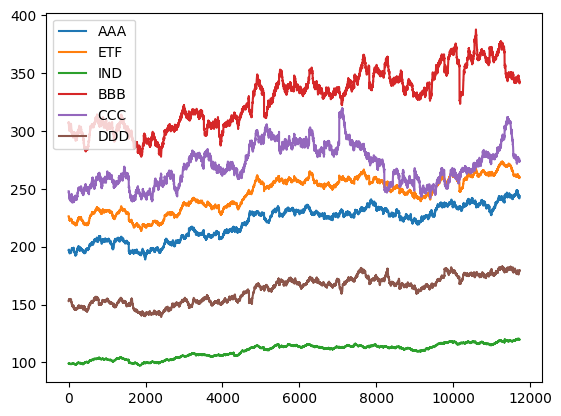

In [4]:
stock_codes=["AAA","ETF","IND","BBB","CCC","DDD"]
#fig, ax = plt.subplots(figsize=(15, 5))
#balance= pd.Series(train_data['resp']).cumsum()
#ax.set_xlabel ("Trade", fontsize=18)
#ax.set_ylabel ("Cumulative resp", fontsize=18);
for name in stock_codes:
    plt.plot(hist_df.index,hist_df[name],label=name)

plt.legend()


In [7]:
df = hist_df[hist_df['day'] < 2]
test_df = hist_df[hist_df['day'] == 2]

In [8]:
all=[]
for i in range(len(stock_codes)):
    pricediff = None
    for j in range(i+1, len(stock_codes)):
        stock_code1 = stock_codes[i]
        stock_code2 = stock_codes[j]
        
        data1 = df[stock_code1]
        data2 = df[stock_code2]

        result=pd.DataFrame()
        result[stock_code1]=data1
        result[stock_code2]=data2
        #print(result.head())
        
        cj = coint_johansen(result[[stock_code1, stock_code2]], det_order=1, k_ar_diff=1)
        
        if cj.trace_stat[0] > cj.trace_stat_crit_vals[0][2]:
            all.append((cj.trace_stat[0],(stock_code1,stock_code2)))
            #print(cj.trace_stat[0],cj.trace_stat_crit_vals[0][2])
            #print(f"Cointegration found for {stock_code1} and {stock_code2}")
            pricediff = result[[stock_code1, stock_code2]] @ cj.evec[0]

all.sort(reverse=True)
print(all)
print(len(all))
#why does everyone has pairtrading potential

[(np.float64(23.211676574573893), ('IND', 'CCC'))]
1


In [26]:
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [31]:
#test 5 days rolling average good pairs
corr_table = pd.DataFrame(index=stock_codes, columns=stock_codes)

for i in range(6): 
    for j in range(6): corr_table.loc[stock_codes[i],stock_codes[j]]=0

for times in range(1,26):
    df=hist_df[hist_df['day']>=times]
    df=df[df['day']<=times+4]
    for i in range(len(stock_codes)):
        for j in range(i+1,len(stock_codes)):
            corr_value = df[stock_codes[i]].corr(df[stock_codes[j]])
            corr_table.loc[stock_codes[i], stock_codes[j]] += corr_value/25
            corr_table.loc[stock_codes[j], stock_codes[i]] += corr_value/25

for code in stock_codes:
    corr_table.loc[code, code] = 1.0

print(corr_table)

          AAA       ETF       IND       BBB       CCC       DDD
AAA       1.0  0.798679  0.869259  0.681547  0.472523  0.649151
ETF  0.798679       1.0  0.839029  0.834761  0.717258  0.793137
IND  0.869259  0.839029       1.0    0.7243   0.50931  0.737952
BBB  0.681547  0.834761    0.7243       1.0  0.328337  0.779764
CCC  0.472523  0.717258   0.50931  0.328337       1.0  0.347302
DDD  0.649151  0.793137  0.737952  0.779764  0.347302       1.0


In [30]:
allcorr_table = pd.DataFrame(index=stock_codes, columns=stock_codes)

for i in range(len(stock_codes)):
    for j in range(i+1,len(stock_codes)):
        corr_value = hist_df[stock_codes[i]].corr(hist_df[stock_codes[j]])
        allcorr_table.loc[stock_codes[i], stock_codes[j]] = corr_value
        allcorr_table.loc[stock_codes[j], stock_codes[i]] = corr_value

for code in stock_codes:
    allcorr_table.loc[code, code] = 1.0

print(allcorr_table)

          AAA       ETF       IND       BBB       CCC       DDD
AAA       1.0  0.968424  0.988981  0.921251   0.59622  0.945258
ETF  0.968424       1.0  0.970013  0.935421  0.707137  0.953985
IND  0.988981  0.970013       1.0  0.924488  0.605363  0.947172
BBB  0.921251  0.935421  0.924488       1.0    0.4347   0.94772
CCC   0.59622  0.707137  0.605363    0.4347       1.0  0.518482
DDD  0.945258  0.953985  0.947172   0.94772  0.518482       1.0


In [10]:

def KFSmoother(prices, initial_state = 0.0):
    """Estimate rolling mean"""
    
    kf = KalmanFilter(transition_matrices=np.eye(1),
                      observation_matrices=np.eye(1),
                      initial_state_mean=initial_state,
                      initial_state_covariance=1,
                      observation_covariance=1,
                      transition_covariance=.05)

    state_means, _ = kf.filter(prices.values)
    return pd.Series(state_means.flatten(),
                     index=prices.index)

def KFHedgeRatio(x, y):
    """Estimate Hedge Ratio"""
    delta = 1e-3
    trans_cov = delta / (1 - delta) * np.eye(2)
    obs_mat = np.expand_dims(np.vstack([[x], [np.ones(len(x))]]).T, axis=1)

    kf = KalmanFilter(n_dim_obs=1, n_dim_state=2,
                      initial_state_mean=[0, 0],
                      initial_state_covariance=np.ones((2, 2)),
                      transition_matrices=np.eye(2),
                      observation_matrices=obs_mat,
                      observation_covariance=2,
                      transition_covariance=trans_cov)

    state_means, _ = kf.filter(y.values)
    return -state_means

In [32]:
filtered_train = {}
for security in stock_codes:
    temp_filter1 = KFSmoother(hist_df[security], hist_df[security][0])
    temp_filter2 = KFSmoother(hist_df[security])
    filtered_train[security] = temp_filter1[30:]

In [21]:
security1="ETF"
security2="BBB"

linear_model = LinearRegression(fit_intercept=True)
linear_model.fit(hist_df[security1].values.reshape(-1,1), hist_df[security2])
linear_model.intercept_, linear_model.coef_

(np.float64(-45.75562197458851), array([1.52293886]))

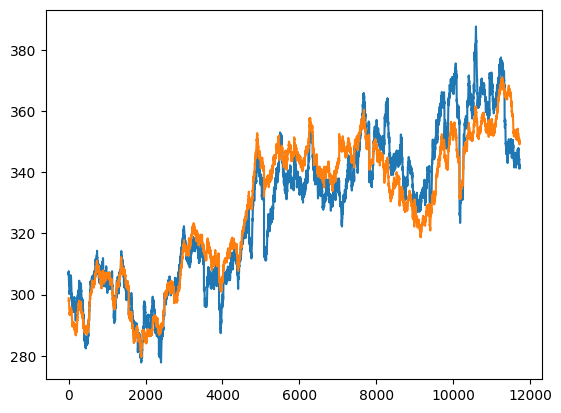

In [22]:
y_fit=linear_model.coef_*hist_df[security1]+linear_model.intercept_
plt.plot(hist_df[security2])
plt.plot(y_fit)

np.float64(8.615719760068005)

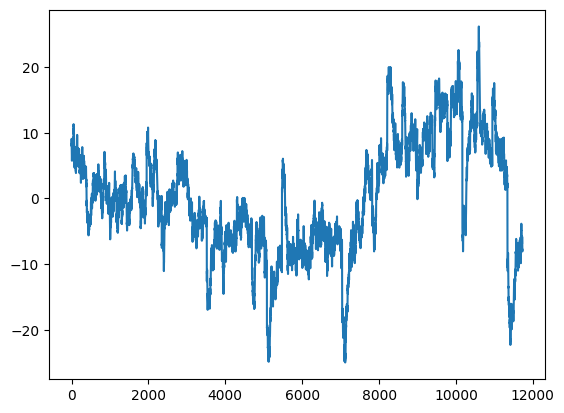

In [23]:
diff=hist_df[security2]-y_fit
diff.plot()
diff.mean()
np.sqrt(diff.var())